# 🏨 Paso 4 — Análisis Descriptivo



Antes de construir cualquier modelo, necesitamos **conocer bien nuestros datos**.


En este paso calculamos:
- **Media**: el valor promedio
- **Mediana**: el valor del medio si ordenas todos los datos
- **Moda**: el valor que más se repite
- **Desviación estándar**: cuánto se alejan los datos de la media
- **Asimetría**: si los datos se concentran más a la izquierda o la derecha
- **Curtosis**: si hay muchos valores extremos (outliers)

También hacemos **contrastes de hipótesis** para confirmar estadísticamente si ciertas variables influyen en las cancelaciones.



## 📦 Celda 1 — Importar librerías

Cargamos las herramientas que vamos a usar durante todo el análisis.

In [13]:
import pandas as pd          # para manejar tablas de datos (DataFrames)
import numpy as np           # para cálculos matemáticos
import matplotlib.pyplot as plt  # para hacer gráficos
import seaborn as sns        # para gráficos más bonitos y fáciles
from scipy import stats      # para los tests estadísticos (hipótesis)

# Estilo visual de los gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)  # tamaño por defecto de los gráficos

# Cargamos el dataset desde el CSV
# Usamos 'hotel_bookings.csv' sin ruta porque está en la misma carpeta
df = pd.read_csv('hotel_bookings.csv')

# Confirmamos cuántas filas y columnas tiene
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 119,390 filas x 32 columnas


## 👀 Celda 2 — Primeras filas del dataset

Vemos cómo están estructurados los datos: qué columnas hay y qué tipo de información contienen.

In [14]:
# .head() muestra las primeras 5 filas del dataset
# Sirve para ver el formato de los datos rápidamente
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 🔍 Celda 3 — Resumen general de columnas

Para cada columna vemos: su tipo de dato, cuántos valores nulos tiene y cuántos valores únicos.

In [15]:
# Creamos una tabla resumen con información básica de cada columna
resumen = pd.DataFrame({
    'tipo': df.dtypes,                                          # tipo de dato (número, texto...)
    'nulos': df.isnull().sum(),                                 # cuántos valores faltan
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2),   # % de valores que faltan
    'valores_unicos': df.nunique()                              # cuántos valores distintos hay
})
resumen

,tipo,nulos,nulos_%,valores_unicos
hotel,str,0,0.00,2
is_canceled,int64,0,0.00,2
lead_time,int64,0,0.00,479
arrival_date_year,int64,0,0.00,3
arrival_date_month,str,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
arrival_date_day_of_month,int64,0,0.00,31
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35
adults,int64,0,0.00,14


## 📊 Celda 4 — Estadísticos básicos de variables numéricas

`.describe()` nos da de golpe: media, desviación estándar, mínimo, máximo y percentiles de todas las variables numéricas.

In [16]:
# .describe() calcula automáticamente los estadísticos principales
# .T gira la tabla para que sea más fácil de leer (filas ↔ columnas)
# .round(2) redondea a 2 decimales
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


## 📐 Celda 5 — Estadísticos ampliados con teoría de distribución

Añadimos moda, asimetría y curtosis, y teorizamos qué distribución sigue cada variable.

**¿Qué es la asimetría?**
- Cerca de 0 → distribución normal (simétrica)
- Positiva alta → la mayoría de valores son bajos pero hay algunos muy altos (cola derecha)
- Negativa → la mayoría de valores son altos pero hay algunos muy bajos

**¿Qué es la curtosis?**
- Alta → hay muchos valores extremos (outliers)
- Baja → los datos están bien concentrados

In [17]:
# Seleccionamos solo las columnas numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Lista vacía donde iremos guardando los estadísticos de cada variable
stats_ampliados = []

# Recorremos cada variable numérica una por una
for col in num_cols:
    serie = df[col].dropna()   # quitamos los valores nulos para calcular bien
    skew = serie.skew()        # calculamos la asimetría
    kurt = serie.kurtosis()    # calculamos la curtosis

    # Decidimos qué distribución teórica sigue según la asimetría
    if abs(skew) < 0.5:
        dist = 'Normal / Uniforme'
    elif skew > 0.5 and skew < 2:
        dist = 'Asimétrica positiva (Log-Normal)'
    elif skew >= 2:
        dist = 'Asimétrica positiva fuerte (Exponencial/Pareto)'
    else:
        dist = 'Asimétrica negativa'

    # Guardamos todos los estadísticos de esta variable
    stats_ampliados.append({
        'Variable':           col,
        'Media':              round(serie.mean(), 2),
        'Mediana':            round(serie.median(), 2),
        'Moda':               round(serie.mode()[0], 2),
        'Desv.Std':           round(serie.std(), 2),
        'Min':                serie.min(),
        'Max':                serie.max(),
        'Asimetría':          round(skew, 3),
        'Curtosis':           round(kurt, 3),
        'Distribución teórica': dist
    })

# Convertimos la lista en una tabla y la mostramos
pd.DataFrame(stats_ampliados).set_index('Variable')

,Media,Mediana,Moda,Desv.Std,Min,Max,Asimetría,Curtosis,Distribución teórica
Variable,,,,,,,,,
is_canceled,0.37,0.00,0.0,0.48,0.00,1.0,0.537,-1.712,Asimétrica positiva (Log-Normal)
lead_time,104.01,69.00,0.0,106.86,0.00,737.0,1.347,1.696,Asimétrica positiva (Log-Normal)
arrival_date_year,2016.16,2016.00,2016.0,0.71,2015.00,2017.0,-0.233,-0.995,Normal / Uniforme
arrival_date_week_number,27.17,28.00,33.0,13.61,1.00,53.0,-0.010,-0.986,Normal / Uniforme
arrival_date_day_of_month,15.80,16.00,17.0,8.78,1.00,31.0,-0.002,-1.187,Normal / Uniforme
stays_in_weekend_nights,0.93,1.00,0.0,1.00,0.00,19.0,1.380,7.174,Asimétrica positiva (Log-Normal)
stays_in_week_nights,2.50,2.00,2.0,1.91,0.00,50.0,2.862,24.285,Asimétrica positiva fuerte (Exponencial/Pareto)
adults,1.86,2.00,2.0,0.58,0.00,55.0,18.318,1352.115,Asimétrica positiva fuerte (Exponencial/Pareto)
children,0.10,0.00,0.0,0.40,0.00,10.0,4.113,18.674,Asimétrica positiva fuerte (Exponencial/Pareto)


## 📈 Celda 6 — Gráficos de distribución de variables numéricas

Un histograma por cada variable numérica importante. La línea **roja** es la media y la **naranja** es la mediana. Si están muy separadas, hay asimetría o outliers.

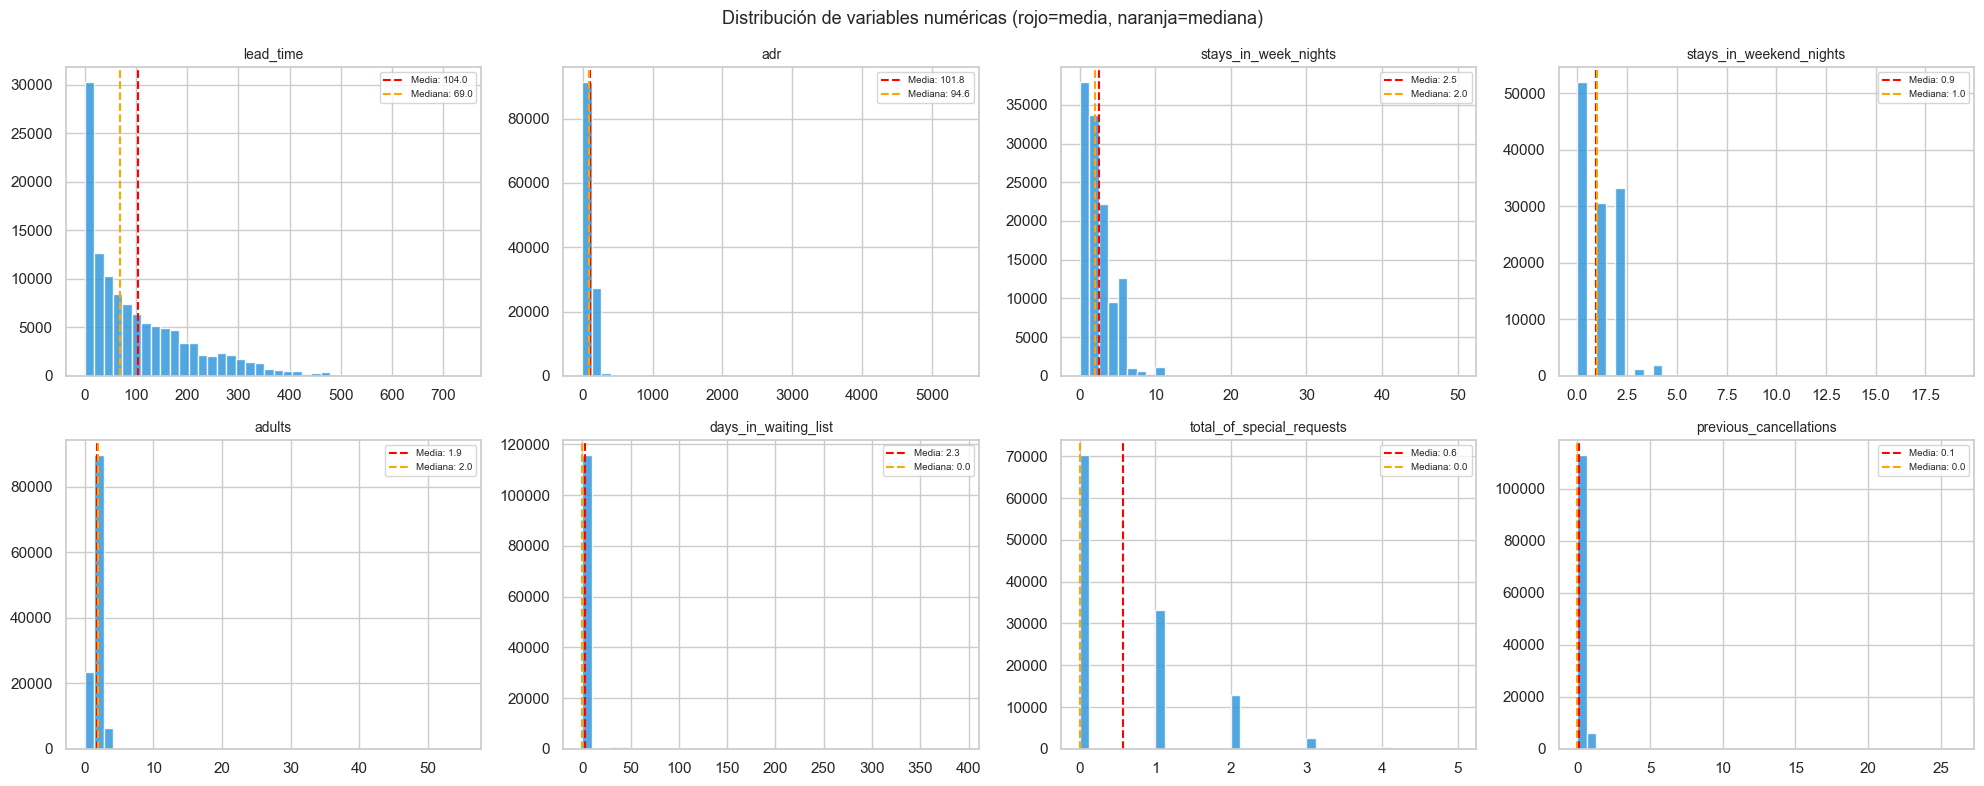

In [18]:
# Las 8 variables numéricas más relevantes para el análisis
vars_plot = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
             'adults', 'days_in_waiting_list', 'total_of_special_requests', 'previous_cancellations']

# Creamos una cuadrícula de 2 filas x 4 columnas para los 8 gráficos
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()  # convertimos la cuadrícula en una lista simple

for i, col in enumerate(vars_plot):
    # Histograma de la variable
    axes[i].hist(df[col].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.85)
    # Línea vertical roja en la media
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Media: {df[col].mean():.1f}')
    # Línea vertical naranja en la mediana
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de variables numéricas (rojo=media, naranja=mediana)', fontsize=13)
plt.tight_layout()
# Guardamos el gráfico como imagen en la misma carpeta
plt.savefig('distribucion_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 Celda 7 — Estadísticos de variables categóricas

Para las variables de texto (hotel, país, tipo de cliente...) no podemos calcular medias. En su lugar vemos cuántas categorías únicas tiene cada una y cuál es la más frecuente (moda).

In [19]:
# Seleccionamos solo las columnas de texto (categóricas)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables categóricas encontradas: {cat_cols}\n')

# Para cada variable categórica mostramos su moda y las 5 categorías más frecuentes
for col in cat_cols:
    print(f'\n🔹 {col}  ({df[col].nunique()} categorías únicas)')
    print(f'   Moda (la más frecuente): {df[col].mode()[0]}')
    # value_counts(normalize=True) da el % de cada categoría
    print(df[col].value_counts(normalize=True).mul(100).round(2).head(5).to_string())

C:\Users\34650\AppData\Local\Temp\ipykernel_9732\3118306648.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Variables categóricas encontradas: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


🔹 hotel  (2 categorías únicas)
   Moda (la más frecuente): City Hotel
hotel
City Hotel      66.45
Resort Hotel    33.55

🔹 arrival_date_month  (12 categorías únicas)
   Moda (la más frecuente): August
arrival_date_month
August     11.62
July       10.60
May         9.88
October     9.35
April       9.29

🔹 meal  (5 categorías únicas)
   Moda (la más frecuente): BB
meal
BB           77.32
HB           12.11
SC            8.92
Undefined     0.98
FB            0.67

🔹 country  (177 categorías únicas)
   Moda (la más frecuente): PRT
country
PRT    40.87
GBR    10.20
FRA     8.76
ESP     7.21
DEU     6.13

🔹 market_segment  (8 categorías únicas)
   Moda (la más frecuente): Online TA
market_segment
Online TA        47.30
Offline TA/TO    20

## 📊 Celda 8 — Gráficos de variables categóricas

Visualizamos cuántas reservas hay por cada categoría en las variables más importantes.

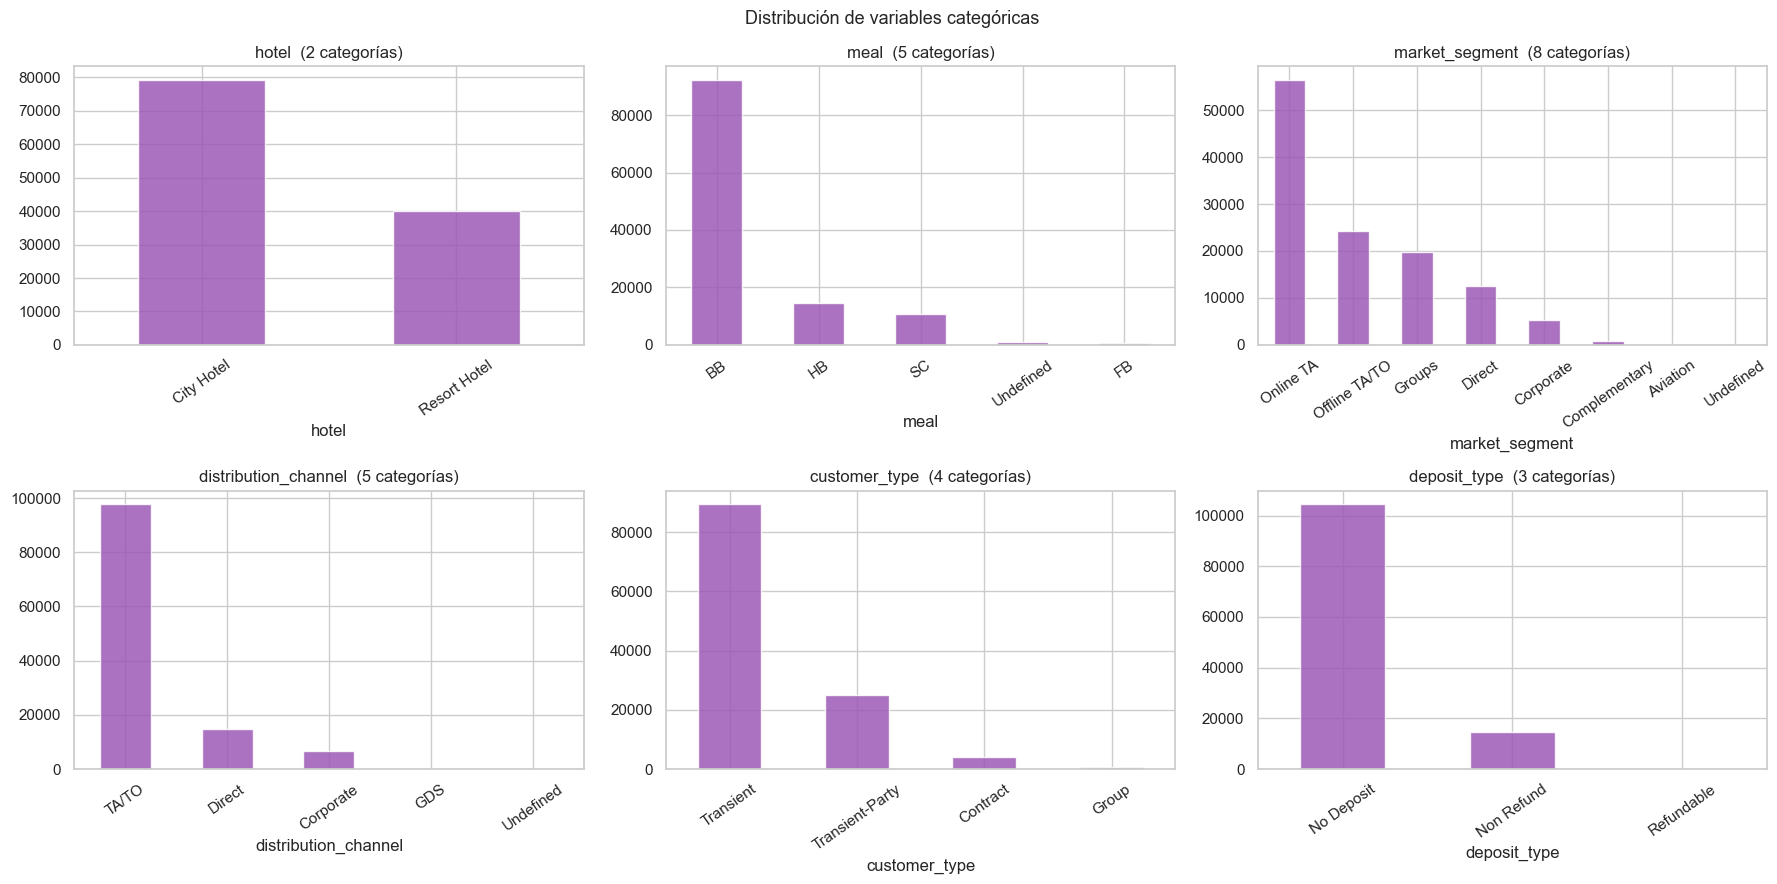

In [20]:
# Las 6 variables categóricas más relevantes
cat_plot = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type', 'deposit_type']

# Cuadrícula de 2 filas x 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    counts = df[col].value_counts()  # contamos cuántas veces aparece cada categoría
    counts.plot(kind='bar', ax=axes[i], color='#9b59b6', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}  ({df[col].nunique()} categorías)')
    axes[i].tick_params(axis='x', rotation=35)

plt.suptitle('Distribución de variables categóricas', fontsize=13)
plt.tight_layout()
plt.savefig('distribucion_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Celda 9 — Variable objetivo: `is_canceled`

Esta es la variable que queremos predecir. Vemos cuántas reservas se cancelaron y cuántas no.

No canceladas: 75,166 (63.0%)
Canceladas:    44,224 (37.0%)


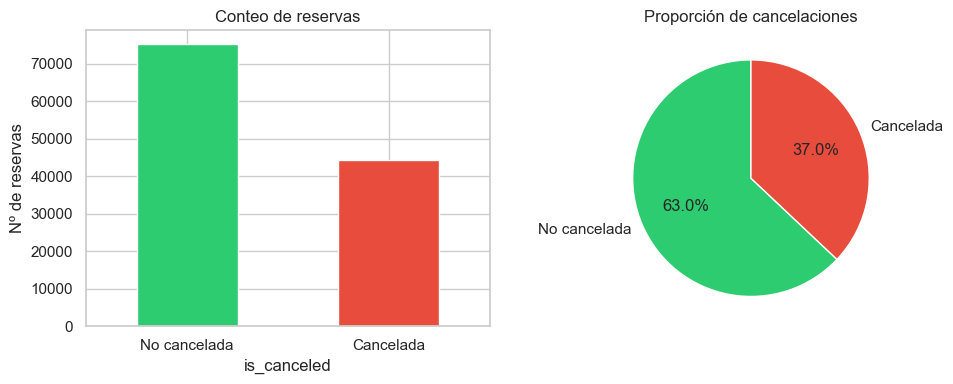

In [21]:
# Contamos cuántas reservas son canceladas (1) y cuántas no (0)
cancelaciones = df['is_canceled'].value_counts()
# Calculamos el porcentaje de cancelaciones
tasa = df['is_canceled'].mean() * 100

print(f'No canceladas: {cancelaciones[0]:,} ({100-tasa:.1f}%)')
print(f'Canceladas:    {cancelaciones[1]:,} ({tasa:.1f}%)')

# Gráfico de barras + gráfico de tarta
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cancelaciones.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_xticklabels(['No cancelada', 'Cancelada'], rotation=0)
axes[0].set_title('Conteo de reservas')
axes[0].set_ylabel('Nº de reservas')

axes[1].pie(cancelaciones, labels=['No cancelada', 'Cancelada'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de cancelaciones')

plt.tight_layout()
plt.savefig('variable_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧪 Celda 10 — Contraste de hipótesis H1: Lead Time

**Pregunta:** ¿Las reservas que se cancelan se hicieron con más antelación?

Usamos el **t-test** (prueba t de Student): compara las medias de dos grupos y nos dice si la diferencia es real o podría ser casualidad.

- Si **p-value < 0.05** → la diferencia es real (rechazamos H0)
- Si **p-value ≥ 0.05** → puede ser casualidad (no rechazamos H0)

In [22]:
# Separamos el lead_time en dos grupos: canceladas y no canceladas
grupo_cancel    = df[df['is_canceled'] == 1]['lead_time']  # reservas canceladas
grupo_no_cancel = df[df['is_canceled'] == 0]['lead_time']  # reservas no canceladas

# Aplicamos el t-test de dos muestras independientes
# H0 (hipótesis nula): el lead_time medio es igual en ambos grupos
t, p = stats.ttest_ind(grupo_cancel, grupo_no_cancel)

print('H0: El lead_time medio es igual en canceladas y no canceladas')
print(f'Lead_time medio canceladas:    {grupo_cancel.mean():.1f} días')
print(f'Lead_time medio no canceladas: {grupo_no_cancel.mean():.1f} días')
print(f'\nEstadístico t = {t:.4f}')
print(f'p-value       = {p:.2e}')

# Interpretamos el resultado
if p < 0.05:
    print('\n✅ RECHAZAMOS H0: el lead_time SÍ influye en la cancelación (p < 0.05)')
    print('   Cuanto más tiempo de antelación, más probable que se cancele')
else:
    print('\n❌ No rechazamos H0: no hay diferencia significativa')

H0: El lead_time medio es igual en canceladas y no canceladas
Lead_time medio canceladas:    144.8 días
Lead_time medio no canceladas: 80.0 días

Estadístico t = 105.9349
p-value       = 0.00e+00

✅ RECHAZAMOS H0: el lead_time SÍ influye en la cancelación (p < 0.05)
   Cuanto más tiempo de antelación, más probable que se cancele


## 🧪 Celda 11 — Contraste de hipótesis H2: Precio (ADR)

**Pregunta:** ¿Las reservas más caras se cancelan más?

Usamos de nuevo el **t-test**, esta vez comparando el precio medio entre canceladas y no canceladas.

In [23]:
# Separamos el precio (ADR) por grupo
adr_cancel    = df[df['is_canceled'] == 1]['adr'].dropna()
adr_no_cancel = df[df['is_canceled'] == 0]['adr'].dropna()

# Eliminamos el 1% de precios más extremos para que no distorsionen el test
adr_cancel    = adr_cancel[adr_cancel < adr_cancel.quantile(0.99)]
adr_no_cancel = adr_no_cancel[adr_no_cancel < adr_no_cancel.quantile(0.99)]

# t-test entre los dos grupos de precio
t2, p2 = stats.ttest_ind(adr_cancel, adr_no_cancel)

print('H0: El precio medio (ADR) es igual en canceladas y no canceladas')
print(f'ADR medio canceladas:    €{adr_cancel.mean():.2f}')
print(f'ADR medio no canceladas: €{adr_no_cancel.mean():.2f}')
print(f'\nEstadístico t = {t2:.4f}')
print(f'p-value       = {p2:.2e}')

if p2 < 0.05:
    print('\n✅ RECHAZAMOS H0: el precio SÍ influye en la cancelación (p < 0.05)')
else:
    print('\n❌ No rechazamos H0: no hay diferencia significativa en el precio')

H0: El precio medio (ADR) es igual en canceladas y no canceladas
ADR medio canceladas:    €103.03
ADR medio no canceladas: €98.10

Estadístico t = 18.3557
p-value       = 3.78e-75

✅ RECHAZAMOS H0: el precio SÍ influye en la cancelación (p < 0.05)


## 🧪 Celda 12 — Contraste de hipótesis H3: Tipo de depósito

**Pregunta:** ¿El tipo de depósito (sin depósito, reembolsable, no reembolsable) afecta la tasa de cancelación?

Aquí usamos **Chi-cuadrado** porque ambas variables son categóricas (no numéricas). El Chi-cuadrado mide si dos variables categóricas están relacionadas o son independientes.

In [24]:
# Tabla de contingencia: cruza tipo de depósito con cancelación
# Nos muestra cuántas reservas hay en cada combinación
tabla = pd.crosstab(df['deposit_type'], df['is_canceled'])

# Test Chi-cuadrado
# H0: el tipo de depósito y la cancelación son independientes (no están relacionados)
chi2, p3, dof, expected = stats.chi2_contingency(tabla)

print('Tabla de contingencia (filas=tipo depósito, columnas=cancelación):')
print(tabla)
print(f'\nChi2 = {chi2:.2f}')
print(f'p-value = {p3:.2e}')
print(f'Grados de libertad = {dof}')

if p3 < 0.05:
    print('\n✅ RECHAZAMOS H0: el tipo de depósito SÍ está relacionado con la cancelación')
    print('   Las reservas sin depósito se cancelan mucho más que las no reembolsables')
else:
    print('\n❌ No rechazamos H0: no hay relación significativa')

Tabla de contingencia (filas=tipo depósito, columnas=cancelación):
is_canceled       0      1
deposit_type              
No Deposit    74947  29694
Non Refund       93  14494
Refundable      126     36

Chi2 = 27677.33
p-value = 0.00e+00
Grados de libertad = 2

✅ RECHAZAMOS H0: el tipo de depósito SÍ está relacionado con la cancelación
   Las reservas sin depósito se cancelan mucho más que las no reembolsables
